# Portfolio Risk with VaR, Expected Shortfall and GARCH

## Notebook 02: VaR and Expected Shortfall

This notebook computes the two risk numbers for the portfolio from notebook 01 in three different ways
and puts them side by side.

- **Value at Risk (VaR)**: the loss that should be exceeded only on 1% of days (99% confidence, 1-day horizon).
- **Expected Shortfall (ES)**: the average loss on those worst 1% of days.

| Method | Idea | Main weakness |
|--------|------|---------------|
| Historical | Take the worst 1% of real past days | Relies on very few observations (about 37 days) and assumes the future looks like the past |
| Parametric (normal) | Assume returns follow a bell curve and use a formula | Real returns have fatter tails than the bell curve |
| Monte Carlo (normal) | Simulate 200,000 random days using the means and correlations of the 8 assets | Same normality assumption, only computed by simulation instead of a formula |

## Setup

- Data: `data/prices.csv`, saved by notebook 01 (daily adjusted prices, 2012 to today).
- Portfolio: equal weights (12.5% each), daily simple returns.
- All numbers are reported as % of portfolio value. VaR of 2% means a loss of 200 USD on a 10,000 USD portfolio.

## Caveats

- Here VaR and ES are estimated on the whole history, so this is a description of the data, not a test of
  the models. The honest out-of-sample test (backtest) comes in notebook 04.
- The historical estimate of ES averages only a few dozen days, so it is noisy.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Load cached prices from notebook 01
px = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True)

# Daily simple returns and equal-weight portfolio
ret = px.pct_change().dropna()
w = np.repeat(1 / ret.shape[1], ret.shape[1])
port = ret @ w   # daily portfolio return

alpha = 0.99     # confidence level: we look at the worst 1% of days
os.makedirs("../figures", exist_ok=True)

print(f"{len(port)} daily observations, {px.index[0].date()} to {px.index[-1].date()}")

3708 daily observations, 2012-01-03 to 2026-10-02


## Are portfolio returns normal?

Two of the three methods assume a bell curve. Before using them, check whether the data agrees.
For a normal distribution, excess kurtosis is 0 and the Jarque-Bera test does not reject normality.

Mean daily return:       0.0541%
Daily std (volatility):  0.8541%
Skewness:                -0.25
Excess kurtosis:         12.09   (0 for a normal distribution)
Jarque-Bera p-value:     0.0000


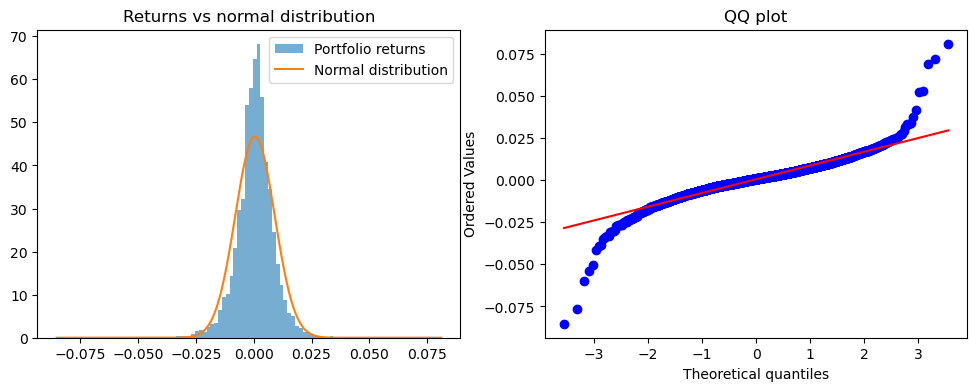

In [3]:
print(f"Mean daily return:       {port.mean():.4%}")
print(f"Daily std (volatility):  {port.std():.4%}")
print(f"Skewness:                {stats.skew(port):.2f}")
print(f"Excess kurtosis:         {stats.kurtosis(port):.2f}   (0 for a normal distribution)")

# Jarque-Bera test: null hypothesis = returns are normally distributed
jb_stat, jb_p = stats.jarque_bera(port)
print(f"Jarque-Bera p-value:     {jb_p:.4f}")

# Visual check: histogram vs normal curve, and QQ plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(port, bins=100, density=True, alpha=0.6, label="Portfolio returns")
x = np.linspace(port.min(), port.max(), 500)
ax[0].plot(x, stats.norm.pdf(x, port.mean(), port.std()), label="Normal distribution")
ax[0].set_title("Returns vs normal distribution")
ax[0].legend()

stats.probplot(port, dist="norm", plot=ax[1])
ax[1].set_title("QQ plot")

plt.savefig("../figures/02_normality.png", dpi=200, bbox_inches="tight")
plt.show()

## Three ways to compute VaR and ES

All three return **positive numbers for losses**. For example, VaR = 0.02 means a 2% loss.

In [4]:
# --- 1) Historical: take the real worst 1% of past days ---
var_h = -np.quantile(port, 1 - alpha)       # loss threshold
es_h = -port[port <= -var_h].mean()         # average loss on days worse than VaR

# --- 2) Parametric: assume returns follow a normal distribution ---
mu, sigma = port.mean(), port.std()
z = stats.norm.ppf(1 - alpha)               # about -2.33 for 99%
var_p = -(mu + sigma * z)
es_p = -mu + sigma * stats.norm.pdf(z) / (1 - alpha)   # closed-form ES for the normal

# --- 3) Monte Carlo: simulate 200,000 days from a multivariate normal ---
# Uses the means and the covariance matrix of the 8 assets, so correlations are included
rng = np.random.default_rng(42)             # fixed seed = reproducible results
sims = rng.multivariate_normal(ret.mean(), ret.cov(), 200_000) @ w
var_mc = -np.quantile(sims, 1 - alpha)
es_mc = -sims[sims <= -var_mc].mean()

results = pd.DataFrame(
    {"VaR 99% (%)": [var_h, var_p, var_mc],
     "ES 99% (%)":  [es_h, es_p, es_mc]},
    index=["Historical", "Parametric (normal)", "Monte Carlo (normal)"],
) * 100
results["ES / VaR"] = results["ES 99% (%)"] / results["VaR 99% (%)"]

n_tail = int((port <= -var_h).sum())
print(f"Historical tail contains {n_tail} days out of {len(port)}")
display(results.round(2))

Historical tail contains 38 days out of 3708


,VaR 99% (%),ES 99% (%),ES / VaR
Historical,2.30,3.32,1.44
Parametric (normal),1.93,2.22,1.15
Monte Carlo (normal),1.93,2.22,1.15


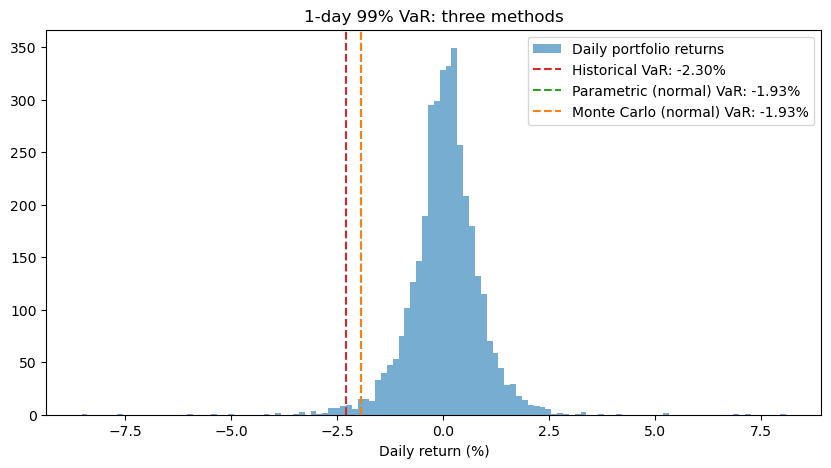

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(port * 100, bins=120, alpha=0.6, label="Daily portfolio returns")
colors = ["tab:red", "tab:green", "tab:orange"]   # one color per method
for name, v, c in zip(results.index, results["VaR 99% (%)"], colors):
    plt.axvline(-v, linestyle="--", color=c, label=f"{name} VaR: -{v:.2f}%")
plt.xlabel("Daily return (%)")
plt.title("1-day 99% VaR: three methods")
plt.legend()

# savefig must come BEFORE plt.show(), otherwise the saved image is blank
plt.savefig("../figures/03_var_methods.png", dpi=200, bbox_inches="tight")
plt.show()

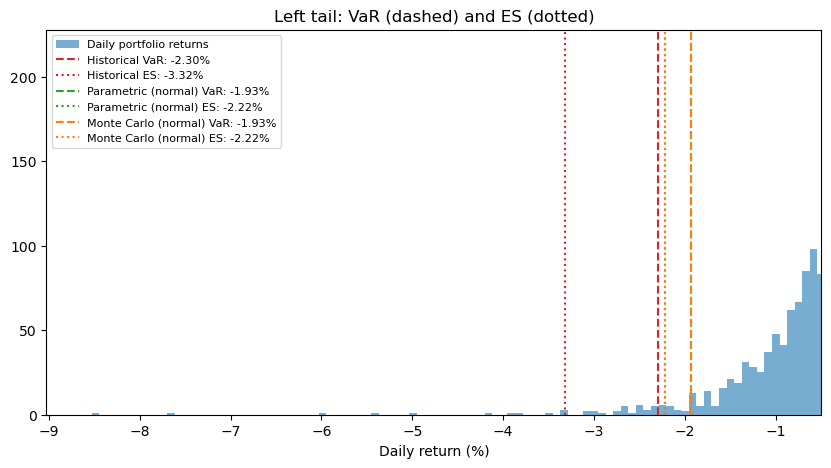

In [6]:
# Zoom into the left tail: where do the methods disagree?
plt.figure(figsize=(10, 5))
plt.hist(port * 100, bins=200, alpha=0.6, label="Daily portfolio returns")
for name, v, e, c in zip(results.index, results["VaR 99% (%)"], results["ES 99% (%)"], colors):
    plt.axvline(-v, linestyle="--", color=c, label=f"{name} VaR: -{v:.2f}%")
    plt.axvline(-e, linestyle=":", color=c, label=f"{name} ES: -{e:.2f}%")
plt.xlim(port.min() * 100 - 0.5, -0.5)
plt.xlabel("Daily return (%)")
plt.title("Left tail: VaR (dashed) and ES (dotted)")
plt.legend(fontsize=8)

plt.savefig("../figures/04_tail_zoom.png", dpi=200, bbox_inches="tight")
plt.show()

## Observations

- Returns are clearly not normal: excess kurtosis is $12.09$ ($0$ for a normal distribution) and the Jarque-Bera
  p-value is $0.0000$, so normality is rejected. The QQ plot bends away from the line in both tails.
- The 99% 1-day VaR is $2.30%$ (historical), $1.93%$ (parametric) and $1.93%$ (Monte Carlo).
- Parametric and Monte Carlo are almost identical, as expected: both assume a normal distribution,
  one uses a formula and the other a simulation.
- Expected Shortfall: historical $3.32%$ vs $2.22%$ for the normal models. The normal models
  underestimate the depth of the tail by about $1.10%$.
- The historical tail is made of only $38$ days, many of them from March 2020, so the historical numbers are noisy
  and dominated by a single crisis.
- These are in-sample numbers: they describe the past, not how the models perform on new data.
  The backtest in notebook 04 does that.